In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing Data
df = pd.read_csv("Zoo.csv")


In [2]:
df = df.drop(columns=['animal name'], axis=1)

In [3]:
y = df['type']
x = df.iloc[:, 1:17]

In [4]:

# Spliting Dataset into Train and Test
from sklearn.model_selection import train_test_split, cross_val_score, KFold
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)


In [5]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(np.ascontiguousarray(X_train))
X_test_scaled = scaler.transform(np.ascontiguousarray(X_test))

In [6]:
# Explore different values of k using k-fold cross-validation
from sklearn.neighbors import KNeighborsClassifier
k_values = list(range(1, 21))
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=KFold(n_splits=5, shuffle=True, random_state=0))
    cv_scores.append(np.mean(scores))

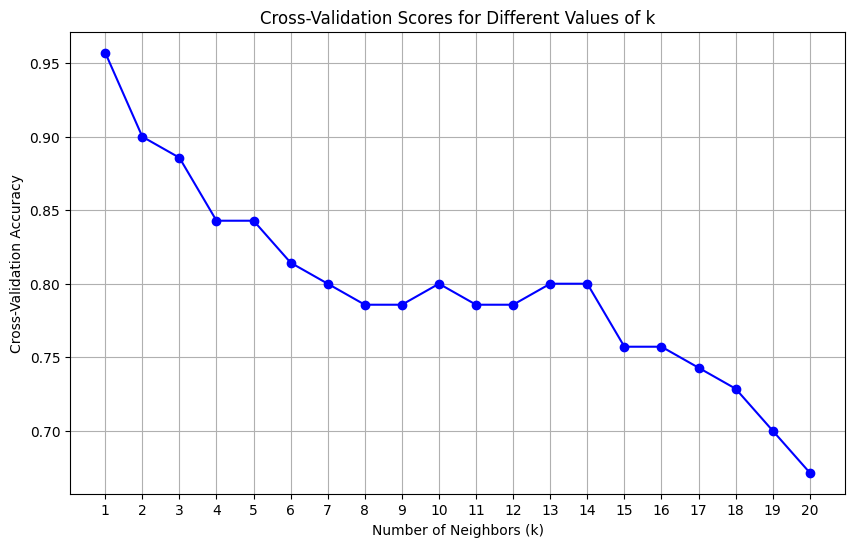

In [7]:
# Plot the cross-validation scores for different values of k
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b')
plt.title('Cross-Validation Scores for Different Values of k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [8]:
# Find the optimal k value
optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal k value based on cross-validation: {optimal_k}")


Optimal k value based on cross-validation: 1


In [9]:
# Train the final model with the optimal k value
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=1)

In [10]:
# Make predictions on the test set
final_y_pred = final_knn.predict(X_test_scaled)

In [11]:
# Evaluate the final model
from sklearn.metrics import accuracy_score
final_accuracy = accuracy_score(y_test, final_y_pred).round(2)
print("Accuracy on the test set with optimal k:",final_accuracy)


Accuracy on the test set with optimal k: 0.97
